In [20]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load the dataset
# The CSV file contains information about songs, including audio features.
df = pd.read_csv('rolling_stones_spotify.csv')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


In [22]:
df.head()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [23]:
df.tail()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
1605,1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,0.1570,0.466,0.932,0.006170,0.3240,-9.214,0.0429,177.340,0.967,39,154080
1606,1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,0.0576,0.509,0.706,0.000002,0.5160,-9.427,0.0843,122.015,0.446,36,245266
1607,1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.3710,0.790,0.774,0.000000,0.0669,-7.961,0.0720,97.035,0.835,30,176080
1608,1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,0.2170,0.700,0.546,0.000070,0.1660,-9.567,0.0622,102.634,0.532,27,121680
1609,1609,Walking The Dog,The Rolling Stones,1964-04-16,12,43SkTJJ2xleDaeiE4TIM70,spotify:track:43SkTJJ2xleDaeiE4TIM70,0.3830,0.727,0.934,0.068500,0.0965,-8.373,0.0359,125.275,0.969,35,189186


In [36]:
df.shape

(1610, 18)

In [24]:
df.columns

Index(['Unnamed: 0', 'name', 'album', 'release_date', 'track_number', 'id',
       'uri', 'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity',
       'duration_ms'],
      dtype='object')

In [35]:
columns_to_drop = [col for col in df.columns if 'Unnamed' in col]

df = df.drop(columns=columns_to_drop)

print(df.columns)

Index(['name', 'album', 'release_date', 'track_number', 'id', 'uri',
       'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity',
       'duration_ms', 'year'],
      dtype='object')


In [37]:
# Convert the 'release_date' column to datetime objects
df['release_date'] = pd.to_datetime(df['release_date'])

# Create a new 'year' feature from the 'release_date' for cohort analysis
df['year'] = df['release_date'].dt.year

# Display the first 5 rows to get a sense of the data
print("First 5 rows of the DataFrame:")
print(df.head())

# Check the data for missing values
print("\nMissing values per column after feature engineering:")
print(df.isnull().sum())

# Drop rows with any missing values to ensure a clean dataset for analysis
df.dropna(inplace=True)

# Select only the relevant audio features for clustering and analysis
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

# Group by year and calculate the average for each audio feature
df_grouped_by_year = df.groupby('year')[audio_features].mean()

print("\nSample of the prepared data grouped by year:\n")
print(df_grouped_by_year.head())

First 5 rows of the DataFrame:
                          name               album release_date  track_number  \
0   Concert Intro Music - Live  Licked Live In NYC   2022-06-10             1   
1   Street Fighting Man - Live  Licked Live In NYC   2022-06-10             2   
2           Start Me Up - Live  Licked Live In NYC   2022-06-10             3   
3  If You Can't Rock Me - Live  Licked Live In NYC   2022-06-10             4   
4            Don’t Stop - Live  Licked Live In NYC   2022-06-10             5   

                       id                                   uri  acousticness  \
0  2IEkywLJ4ykbhi1yRQvmsT  spotify:track:2IEkywLJ4ykbhi1yRQvmsT        0.0824   
1  6GVgVJBKkGJoRfarYRvGTU  spotify:track:6GVgVJBKkGJoRfarYRvGTU        0.4370   
2  1Lu761pZ0dBTGpzxaQoZNW  spotify:track:1Lu761pZ0dBTGpzxaQoZNW        0.4160   
3  1agTQzOTUnGNggyckEqiDH  spotify:track:1agTQzOTUnGNggyckEqiDH        0.5670   
4  7piGJR8YndQBQWVXv6KtQw  spotify:track:7piGJR8YndQBQWVXv6KtQw        0.4000

# STEP 2

The two albums that should be recommended are:
album
Exile On Main Street (Deluxe Version)    18
Honk (Deluxe)                            18
Name: count, dtype: int64


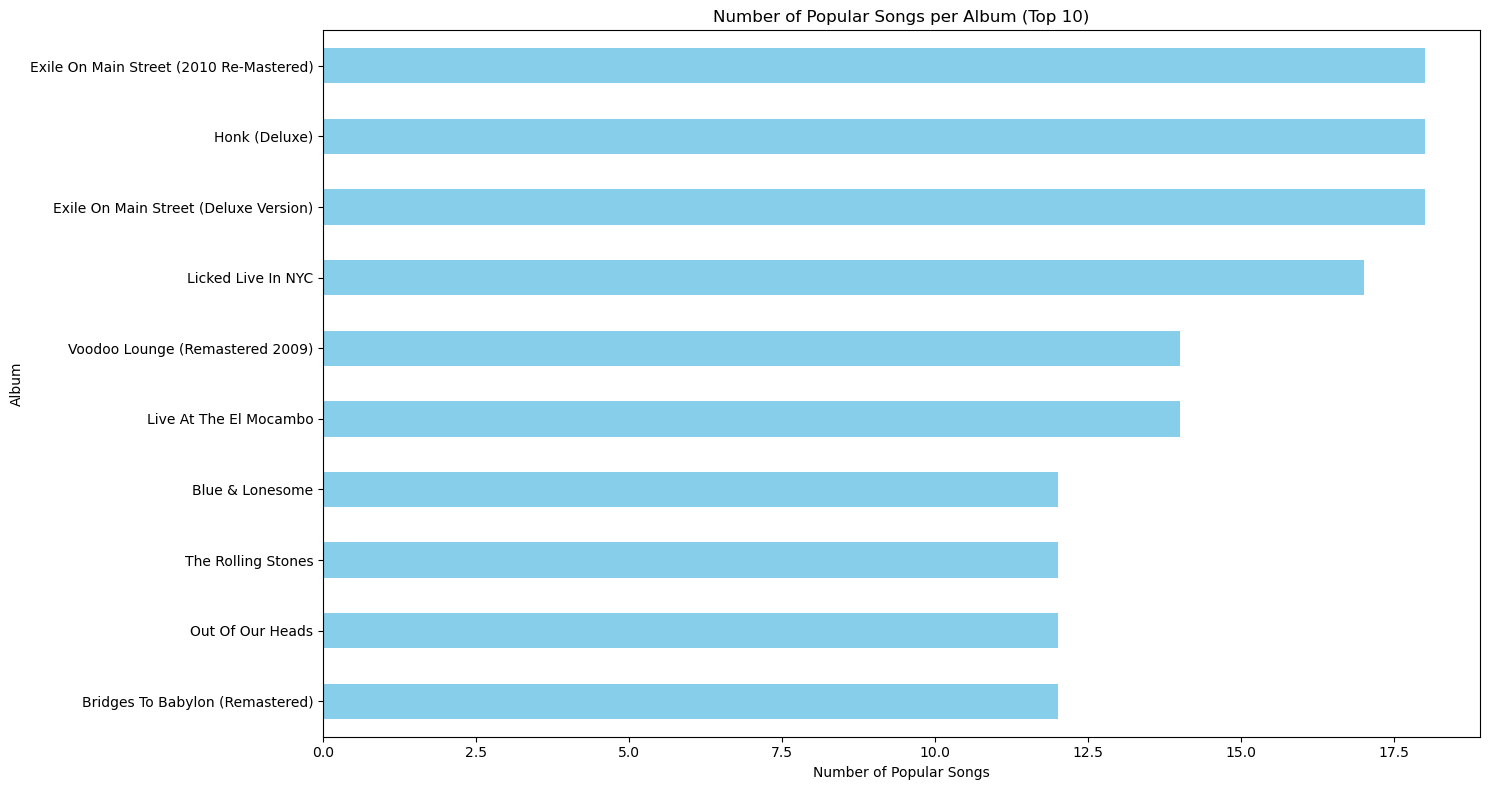

In [38]:
# Define a 'popular song' as one with a popularity score above the 75th percentile.
popular_threshold = df['popularity'].quantile(0.75)

# Filter the DataFrame to include only popular songs.
popular_songs_df = df[df['popularity'] >= popular_threshold]

# Count the number of popular songs for each album.
popular_songs_per_album = popular_songs_df['album'].value_counts()

# Get the top 2 albums with the most popular songs.
top_2_albums = popular_songs_per_album.head(2)

print("The two albums that should be recommended are:")
print(top_2_albums)

# Visualize the number of popular songs in the top 10 albums.
plt.figure(figsize=(15, 8))
top_10_albums = popular_songs_per_album.head(10)
top_10_albums.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Number of Popular Songs per Album (Top 10)')
plt.xlabel('Number of Popular Songs')
plt.ylabel('Album')
plt.tight_layout()
plt.show()

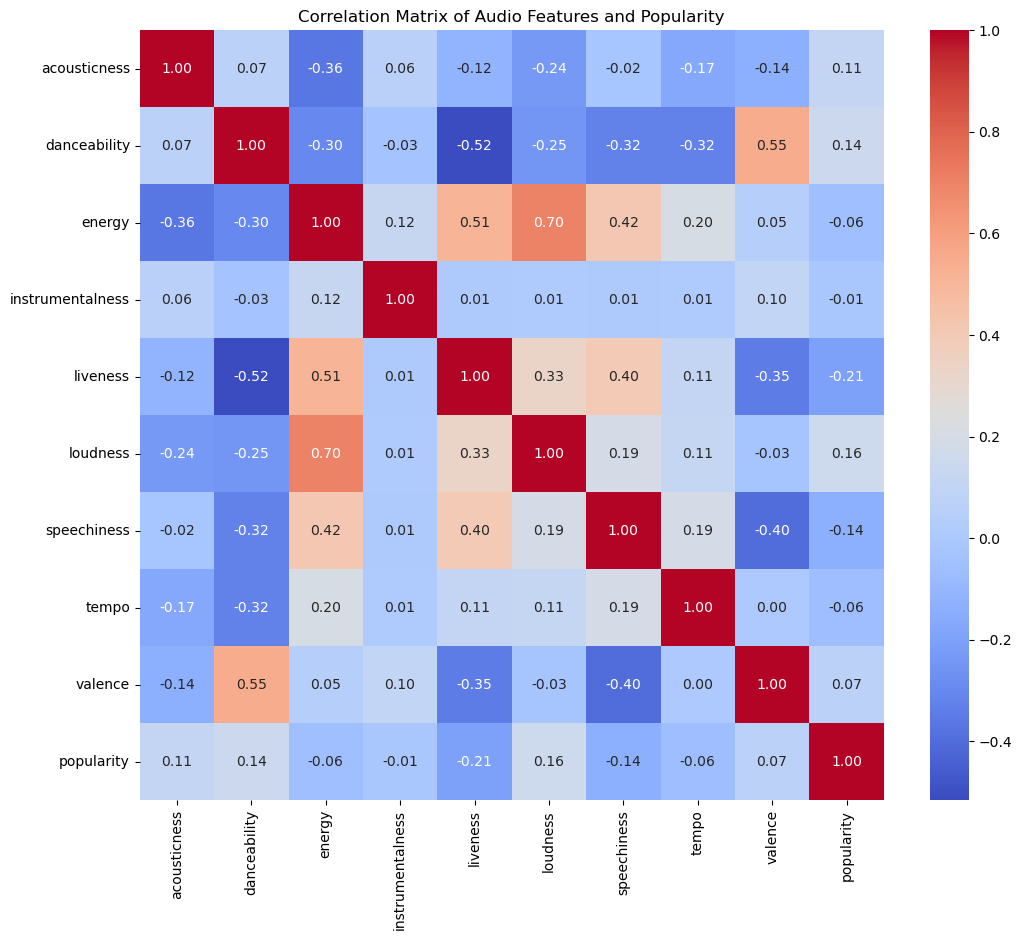

In [39]:
# Select the numerical audio features and popularity for correlation analysis.
correlation_features = audio_features + ['popularity']

# Calculate the correlation matrix.
correlation_matrix = df[correlation_features].corr()

# Visualize the correlation matrix using a heatmap.
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Audio Features and Popularity')
plt.show()

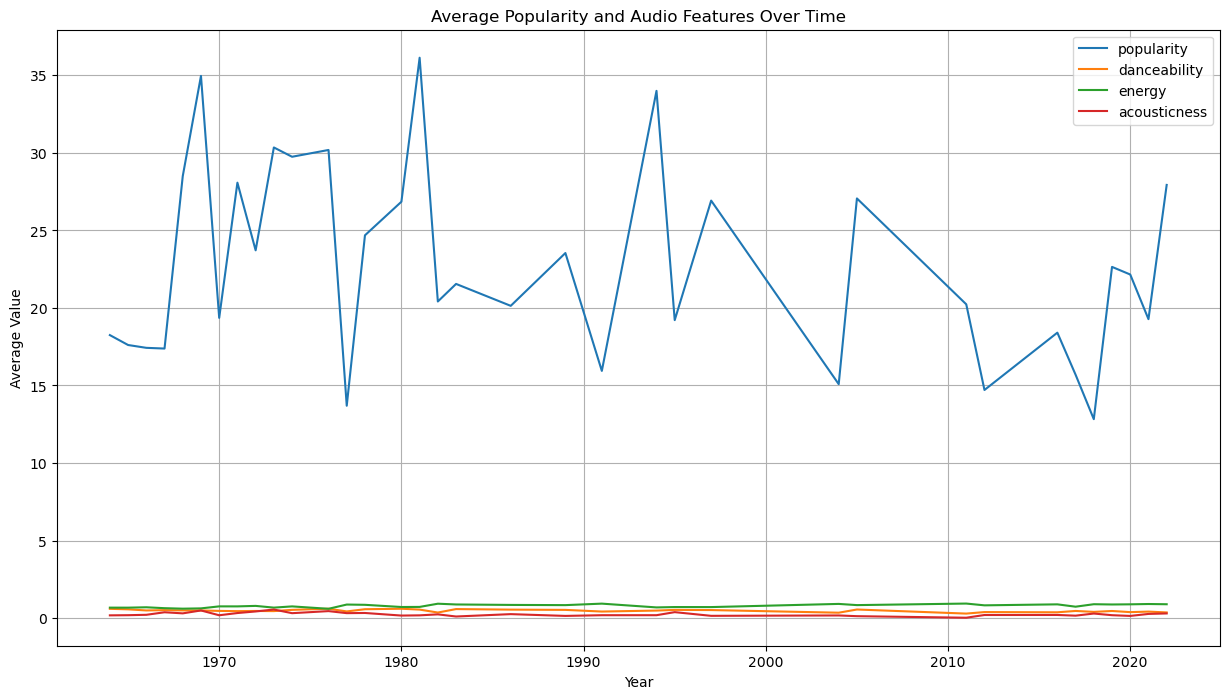

In [40]:
# Group the data by year and calculate the mean of key features and popularity.
time_series_data = df.groupby('year')[['popularity', 'danceability', 'energy', 'acousticness']].mean()

# Plot the time-series trends.
plt.figure(figsize=(15, 8))
time_series_data.plot(ax=plt.gca())
plt.title('Average Popularity and Audio Features Over Time')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.grid(True)
plt.show()

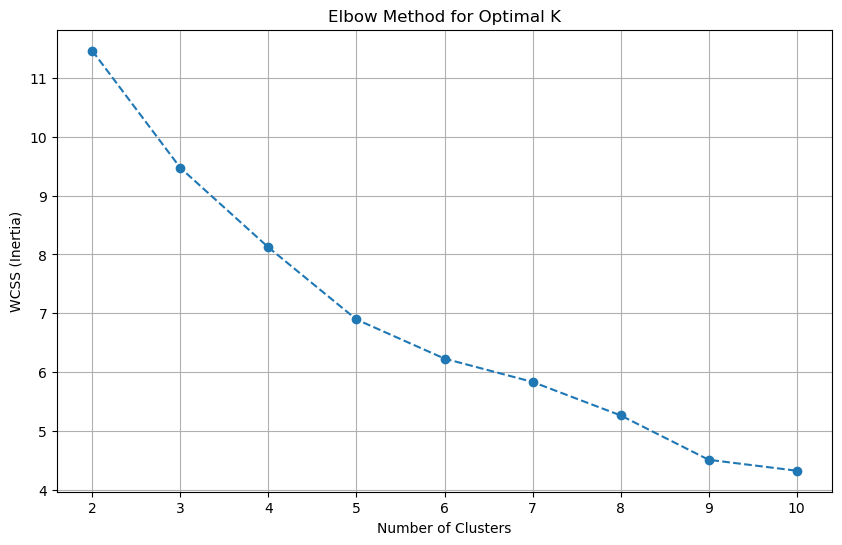

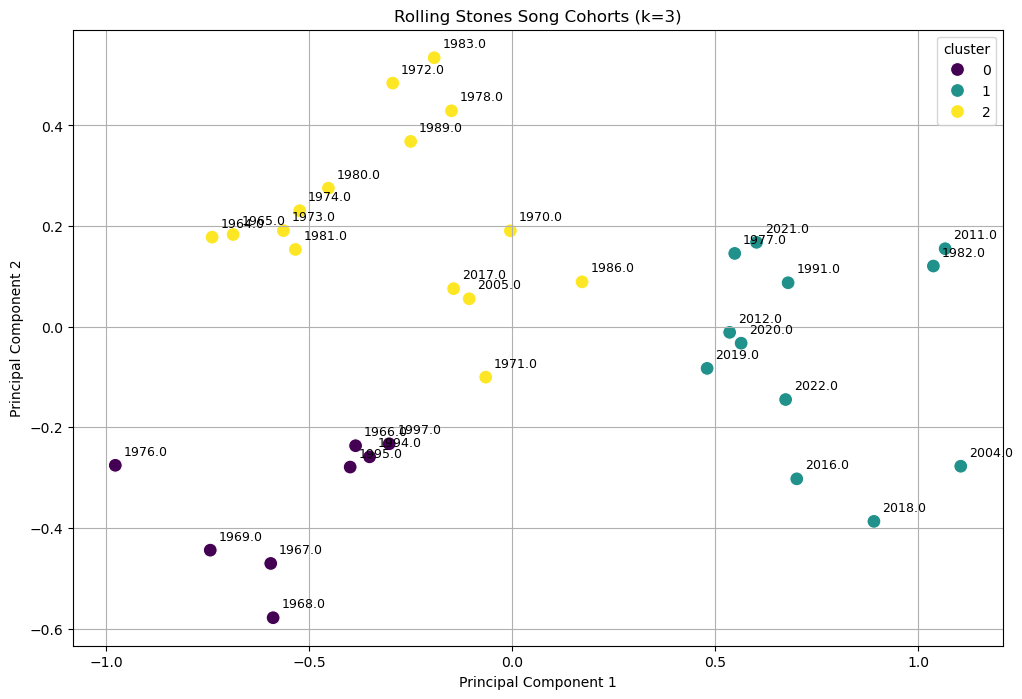


Analysis of Clusters (Mean of Audio Features):

         acousticness  danceability    energy  instrumentalness  liveness  \
cluster                                                                     
0            0.320005      0.517457  0.661181          0.048074  0.237714   
1            0.211959      0.387502  0.897304          0.155697  0.804247   
2            0.242383      0.528386  0.768005          0.218329  0.318586   

         loudness  speechiness       tempo   valence  
cluster                                               
0       -8.621503     0.050296  119.561184  0.571798  
1       -5.505658     0.094529  131.429103  0.508534  
2       -7.087308     0.055438  124.948025  0.677652  


In [41]:
# Normalize the data using MinMaxScaler.
# This ensures that all features are on the same scale, which is crucial for clustering algorithms.
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(df_grouped_by_year)

# Use the Elbow Method to find the optimal number of clusters (k).
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(normalized_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method to visualize the optimal number of clusters.
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

# Based on the elbow plot, the optimal number of clusters is 3.
optimal_k = 3

# Perform K-Means clustering with the optimal number of clusters.
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(normalized_features)

# Add the cluster labels to the grouped DataFrame.
df_grouped_by_year['cluster'] = clusters

# Perform PCA to reduce the data to 2 components for visualization.
pca = PCA(n_components=2)
principal_components = pca.fit_transform(normalized_features)

# Create a DataFrame for the PCA results to be used for plotting.
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters
pca_df['year'] = df_grouped_by_year.index

# Visualize the clusters using a scatterplot.
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=100)
for i in range(len(pca_df)):
    plt.text(pca_df.iloc[i]['PC1'] + 0.02, pca_df.iloc[i]['PC2'] + 0.02, str(pca_df.iloc[i]['year']), fontsize=9)
plt.title(f'Rolling Stones Song Cohorts (k={optimal_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Define each cluster based on its features by examining the mean values.
cluster_analysis = df_grouped_by_year.groupby('cluster')[audio_features].mean()
print("\nAnalysis of Clusters (Mean of Audio Features):\n")
print(cluster_analysis)

In [42]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(normalized_features, clusters)
print(f"The Silhouette Score for k={optimal_k} is: {silhouette_avg:.2f}")

The Silhouette Score for k=3 is: 0.28


In [43]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define features (X) and target (y)
X = df[audio_features]
y = df['popularity']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions and evaluate the model
predictions = dt_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error of the Decision Tree Regressor: {mse:.2f}")

Mean Squared Error of the Decision Tree Regressor: 312.77


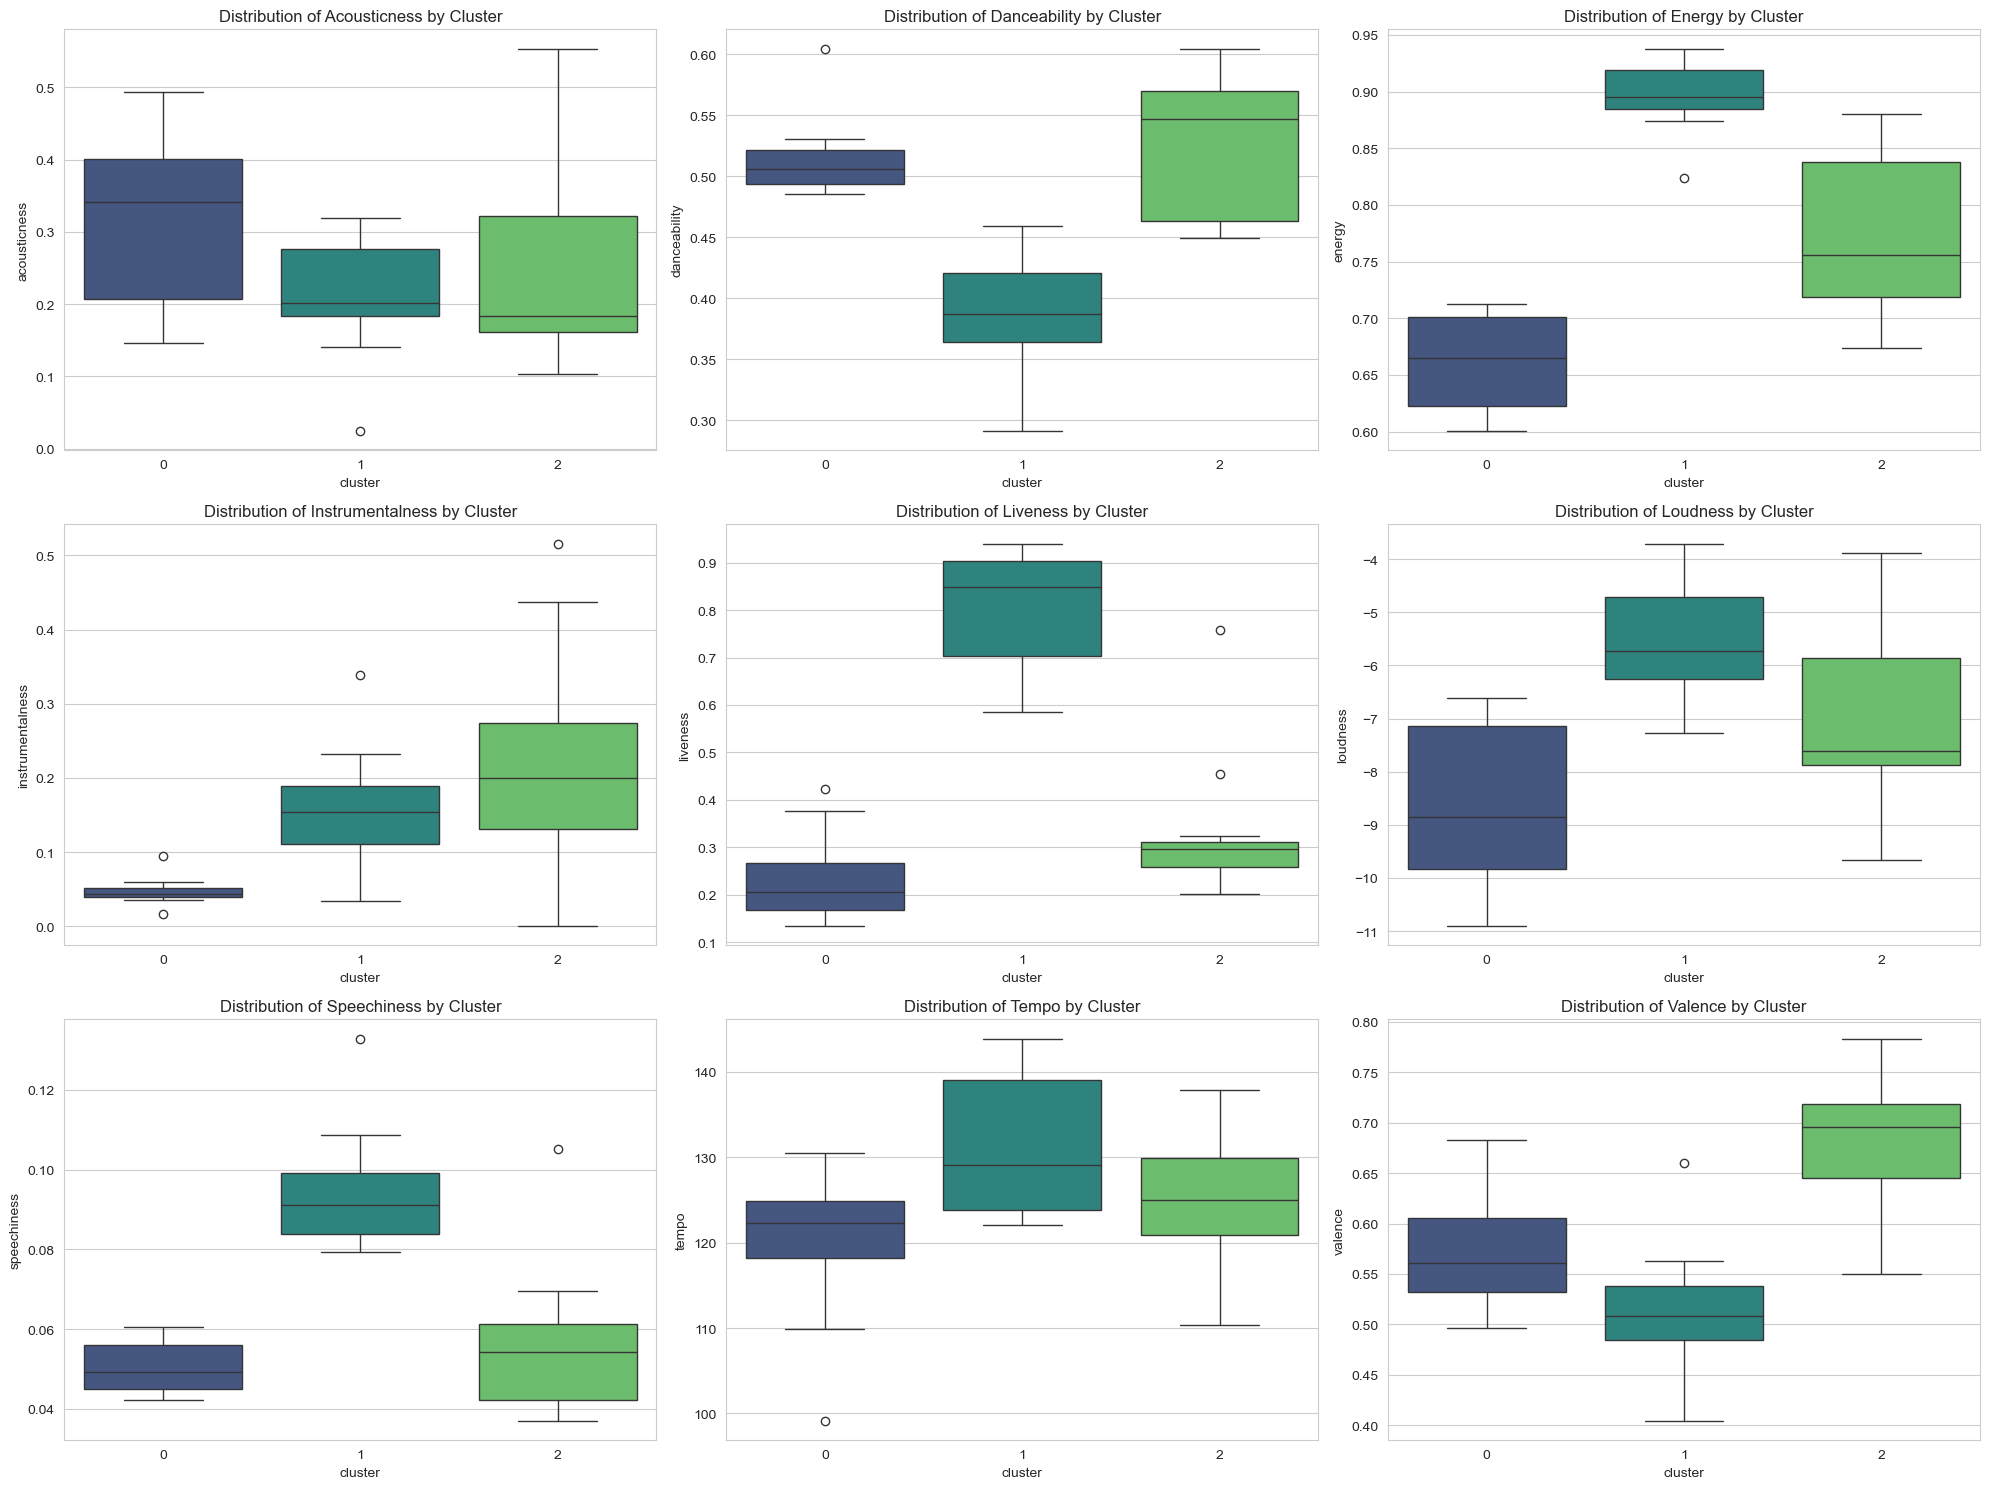

In [51]:
# Assuming 'df_grouped_by_year' has been created and has a 'cluster' column.
# Select the audio features from the grouped DataFrame.
audio_features = list(df_grouped_by_year.columns.drop('cluster'))

# Set up the plotting style
sns.set_style("whitegrid")
plt.figure(figsize=(20, 15))

# Loop through each audio feature and create a box plot
for i, feature in enumerate(audio_features):
    plt.subplot(3, 3, i + 1)
    # Use df_grouped_by_year as the data source
    sns.boxplot(x='cluster', y=feature, data=df_grouped_by_year, palette='viridis')
    plt.title(f'Distribution of {feature.title()} by Cluster')
    plt.tight_layout()

plt.show()

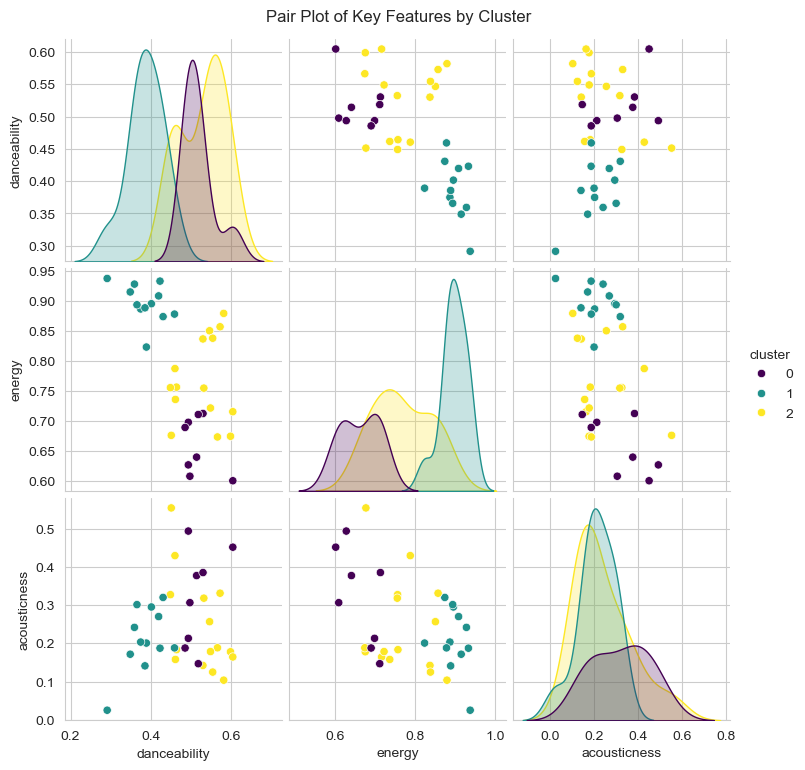

In [52]:
# Assuming 'df_grouped_by_year' has been created and has a 'cluster' column.

# Select a subset of features for the pair plot, including the 'cluster' column.
pair_plot_features = ['danceability', 'energy', 'acousticness', 'cluster']

# Create a pair plot using the grouped DataFrame.
sns.pairplot(df_grouped_by_year[pair_plot_features], hue='cluster', palette='viridis')
plt.suptitle('Pair Plot of Key Features by Cluster', y=1.02)
plt.show()